In [1]:
import os

os.chdir("/ceph/behrens/peter_doohan/goalNav_mFC/experiment/code")
print("Current Working Directory: ", os.getcwd())

Current Working Directory:  /ceph/behrens/peter_doohan/goalNav_mFC/experiment/code


In [2]:
from importlib import reload
from matplotlib import pyplot as plt

plt.rcParams.update(
    {
        "font.size": 10,
        "axes.titlesize": 10,
        "axes.labelsize": 10,
        "xtick.labelsize": 8,
        "ytick.labelsize": 8,
        "legend.fontsize": 8,
        "figure.titlesize": 10,
        "pdf.fonttype": 42,
    }
)

In [3]:
from pathlib import Path

FIG_SAVE_PATH = Path("../results2/figures/6.neGLM")

In [4]:
from GridMaze.analysis.neGLM import load_model_sets as lms
from GridMaze.analysis.neGLM import model_comparisons as mc

reload(lms)
reload(mc)

<module 'GridMaze.analysis.neGLM.model_comparisons' from '/ceph/behrens/peter_doohan/goalNav_mFC/experiment/code/GridMaze/analysis/neGLM/model_comparisons.py'>

## Model validation
Confirm neGLM works better than baselineGLMs

baseline vs embedding:
                      feature_group model_type     t_stat     p_val  \
0                   place_direction  baseline2   7.985724  0.000497   
1                   place_direction   baseline  11.806885  0.000077   
2  place_direction_distance_to_goal  baseline2   8.241120  0.000429   
3  place_direction_distance_to_goal   baseline  11.308994  0.000095   
4                             place   baseline   6.054119  0.001773   

   p_val_corr  
0    0.000621  
1    0.000236  
2    0.000621  
3    0.000236  
4    0.001773  


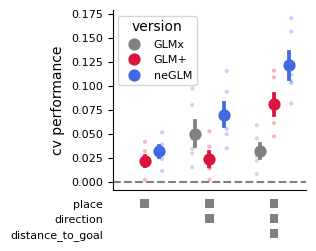

In [5]:
reload(mc)
nbe_validation = lms.load_model_set_cv_scores(
    model_set="performance_validation", maze_names=["maze_1", "maze_2", "rooms_maze"], all_completed=True
)
f, axes = plt.subplots(2, 1, sharex=True, figsize=(2.5, 3), gridspec_kw={"height_ratios": [4, 1], "hspace": 0.05})
mc.plot_performance_validation(nbe_validation, plot_single_subjects=True, axes=axes)
f.savefig(FIG_SAVE_PATH / "performance_validation.pdf")

### Interaction validation
Nested-model comparison testing whether the model needs place×direction interactions and place-direction×distance-to-goal interactions (factorised vs. nonlinear conjunction).

place_direction_factorised vs place_direction_nonlinear
t_stat: -5.306830646355353, p_val: 0.003174222287973421
place_direction_distance_to_goal_factorised vs place_direction_distance_to_goal_nonlinear
t_stat: 1.4179475992257404, p_val: 0.2154064267641584


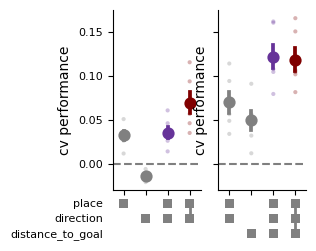

In [6]:
reload(mc)
interaction_validation_results = lms.load_model_set_cv_scores(
    "interaction_validation", maze_names=["maze_1", "maze_2", "rooms_maze"], all_completed=True
)

f, axes = plt.subplots(
    2,
    2,
    figsize=(2.5, 3),
    sharey="row",
    gridspec_kw={"height_ratios": [4, 1], "hspace": 0.05},
)
mc.plot_interaction_validation(
    interaction_validation_results,
    models=["place", "direction", "place_direction_factorised", "place_direction_nonlinear"],
    plot_single_subjects=True,
    colors=["grey", "grey", "rebeccapurple", "maroon"],
    axes=axes[:, 0],
)
mc.plot_interaction_validation(
    interaction_validation_results,
    models=[
        "place_direction_conjunction",
        "distance_to_goal",
        "place_direction_distance_to_goal_factorised",
        "place_direction_distance_to_goal_nonlinear",
    ],
    plot_single_subjects=True,
    colors=["grey", "grey", "rebeccapurple", "maroon"],
    axes=axes[:, 1],
)
f.savefig(FIG_SAVE_PATH / "interaction_validation.pdf")

In [7]:
from GridMaze.analysis.neGLM import variance_explained as ve
from GridMaze.analysis.neGLM import variance_explained_null as nul

reload(ve)

<module 'GridMaze.analysis.neGLM.variance_explained' from '/ceph/behrens/peter_doohan/goalNav_mFC/experiment/code/GridMaze/analysis/neGLM/variance_explained.py'>

## Variance explained by neGLM features
Using the fitted neGLM to ask which task features explain neural variance, how their contributions overlap, and whether the observed structure could arise from arbitrary mixed selectivity.

In [8]:
reload(ve)
late_sessions = False
model_set_name = "variance_explained" if late_sessions else "variance_explained_all_sessions"
variance_explained_results = lms.load_model_set_cv_scores(
    model_set_name, maze_names=["maze_1", "maze_2", "rooms_maze"], all_completed=True
)
reduced_models = [
    "remove_distance_to_goal",
    "remove_place_direction",
]

cpd_df = nul.get_cpd_df(variance_explained_results, r2_thres=0.075)
feature_tuned_df = nul.get_feature_tuned_df(variance_explained_results, r2_thres=0.075, alpha=0.01)


models = [f.split("_", 1)[-1] for f in reduced_models]

### Variance explained per feature (CPD)
Coefficient of partial determination when dropping distance-to-goal vs. place-direction from the full model — how much each feature uniquely contributes.

            feature    t_stat     p_val  p_val_corr
0  distance_to_goal  6.106832  0.000853    0.000853
1   place_direction  8.762988  0.000160    0.000321


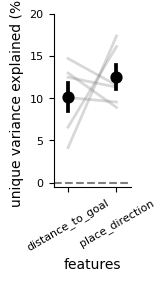

In [9]:
reload(nul)
f, ax = plt.subplots(figsize=(1, 3 * (3 / 4)))
nul.plot_variance_explained(
    cpd_df,
    plot_single_subject=True,
    marker_color=["black", "black"],
    print_stats=True,
    ax=ax,
)
ax.set_ylim(-0.5, 20)
f.savefig(FIG_SAVE_PATH / "variance_explained_cpd.pdf")

### Feature-tuned neuron Venn diagram
Counts of neurons significantly tuned to place-direction, distance-to-goal, both, or neither.

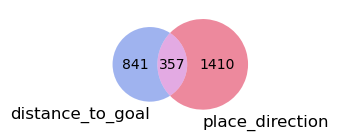

In [10]:
fig, ax = plt.subplots(1, 1, figsize=(2, 2))
nul.plot_feature_venn(
    feature_tuned_df,
    colors=("royalblue", "crimson"),
    ax=ax,
)
fig.savefig(FIG_SAVE_PATH / "venn_diagram.pdf")

### Joint CPD distribution (2D)
Per-neuron CPD for place-direction vs. distance-to-goal as a 2D histogram — visualising the joint structure of feature tuning across the population.

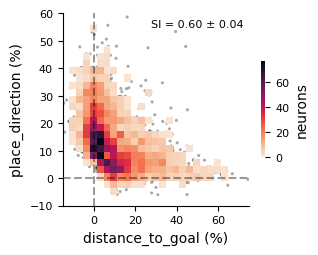

In [11]:
reload(nul)
cpd2d_kwargs = dict(cmap="rocket_r", xlims=(-15, 75), ylims=(-10, 60))
f, ax = plt.subplots(1, 1, figsize=(3, 2.5))
nul.plot_cpd_2d(cpd_df, **cpd2d_kwargs, ax=ax)
f.savefig(FIG_SAVE_PATH / "cpd_2d_hist.pdf")

### Null comparison: full mixed selectivity
Compares the observed CPD structure to a null in which the latent-to-neuron mapping is randomly rotated — forcing features to be fully mixed across neurons. Tests whether the structured selectivity above could arise from arbitrary mixed selectivity.

In [12]:
reload(lms)
reload(nul)
ridge_df, perm_df = nul.load_null_data()

In [13]:
ridge_cpd_df = nul.get_cpd_df(ridge_df)
perm_cpd_df = nul.get_cpd_df(perm_df[perm_df.permutation == 0])

### Ridge-from-latents validation
Same 2D CPD histogram, but computed from a ridge regression on the neGLM latents rather than the Poisson model — confirming the structure is not an artefact of the encoding model.

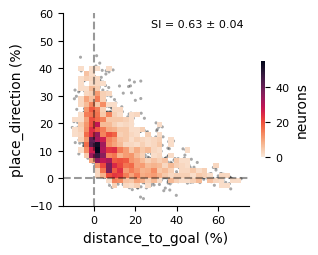

In [14]:
# confirm ridge from latents works ok (similar to Poisson above)
f, ax = plt.subplots(1, 1, figsize=(3, 2.5))
nul.plot_cpd_2d(ridge_cpd_df, **cpd2d_kwargs, ax=ax)
f.savefig(FIG_SAVE_PATH / "cpd_2d_hist_ridge.pdf")

### Example rotation null
CPD distribution under one realisation of the rotation null, where neurons are forced to mix features.

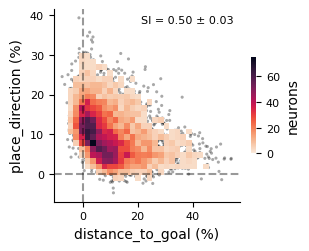

In [15]:
# plot example permutation (where neurons have been randomly rotated such that reps must be mixed across neurons)
f, ax = plt.subplots(1, 1, figsize=(3, 2.5))
nul.plot_cpd_2d(perm_cpd_df, cmap="rocket_r", vmax=75, ax=ax)
f.savefig(FIG_SAVE_PATH / "cpd_2d_hist_permutation.pdf")

### Rotation null distribution
Summary statistic across many rotation nulls vs. the observed value, quantifying how unlikely the observed structured selectivity is under the mixed-selectivity null.

metric: mean_selectivity  (random-effects: n_subjects=6)
  null mean: 0.5027  std: 0.0039  n_perms: 1000
  Poisson: 0.6001 ± 0.0411  p=0.0000
  Ridge:   0.6254 ± 0.0382  p=0.0000


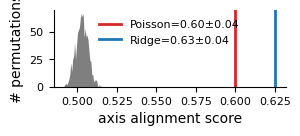

In [16]:
reload(nul)
# plot null distribution
f, ax = plt.subplots(1, 1, figsize=(3, 1))
nul.plot_rotation_null(variance_explained_results, ridge_df, perm_df, print_stats=True, ax=ax)
f.savefig(FIG_SAVE_PATH / "rotation_null.pdf")

In [17]:
results_df = lms.load_model_set_cv_scores(
    "other_features", maze_names=["maze_1", "maze_2", "rooms_maze"], all_completed=False
)

In [18]:
results_df.model_name.unique()

array(['place_direction.distance_to_goal.goal.egocentric_action.velocity',
       'place_direction.distance_to_goal.goal',
       'place_direction.distance_to_goal.goal.egocentric_action.speed',
       'place_direction.distance_to_goal',
       'place_direction.distance_to_goal.goal.egocentric_action',
       'place_direction.distance_to_goal.goal.egocentric_action.velocity.head_direction',
       'place_direction.distance_to_goal.goal.egocentric_action.velocity.head_direction.egocentric_angle_to_goal',
       'place_direction'], dtype=object)

## Other behavioural features
Extending the model with further candidate features (goal identity, egocentric action, velocity, head direction, egocentric angle to goal) to test whether they boost fit beyond place-direction + distance-to-goal.

### Cumulative variance explained as features are added
Cross-validated R² across nested models that progressively add features, showing each feature's marginal contribution.

                                             model_1  \
0                                    place_direction   
1                   place_direction.distance_to_goal   
2              place_direction.distance_to_goal.goal   
3  place_direction.distance_to_goal.goal.egocentr...   
4  place_direction.distance_to_goal.goal.egocentr...   
5  place_direction.distance_to_goal.goal.egocentr...   

                                             model_2     t_stat     p_val  \
0                   place_direction.distance_to_goal   4.288148  0.003901   
1              place_direction.distance_to_goal.goal  -1.831803  0.936763   
2  place_direction.distance_to_goal.goal.egocentr...   7.465190  0.000340   
3  place_direction.distance_to_goal.goal.egocentr...  15.430188  0.000010   
4  place_direction.distance_to_goal.goal.egocentr...   7.807172  0.000276   
5  place_direction.distance_to_goal.goal.egocentr...   3.020907  0.014693   

   p_val_corr  
0    0.005852  
1    0.936763  
2    0.000681  
3  

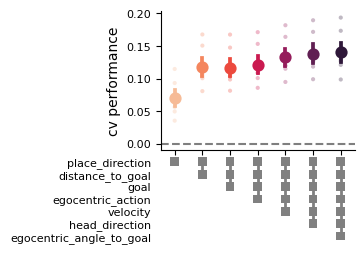

In [19]:
reload(mc)
f, axes = plt.subplots(2, 1, figsize=(2.5, 3), gridspec_kw={"height_ratios": [4, 2.5], "hspace": 0.05})
mc.plot_other_feature_results(
    results_df,
    models=[
        "place_direction",
        "place_direction.distance_to_goal",
        "place_direction.distance_to_goal.goal",
        "place_direction.distance_to_goal.goal.egocentric_action",
        "place_direction.distance_to_goal.goal.egocentric_action.velocity",
        "place_direction.distance_to_goal.goal.egocentric_action.velocity.head_direction",
        "place_direction.distance_to_goal.goal.egocentric_action.velocity.head_direction.egocentric_angle_to_goal",
    ],
    plot_single_subjects=True,
    print_stats=True,
    axes=axes,
)
f.savefig(FIG_SAVE_PATH / "other_feature_results.pdf")

### Proportion of max variance explained per feature
Per-feature share of the total variance reached by the full model, showing how the gains decompose across features.

subject_ID
m2    86.613832
m3    86.849565
m4    81.956969
m6    82.608488
m7    83.048121
m8    81.867931
dtype: float64
mean ± sem: 83.82 ± 0.94 %


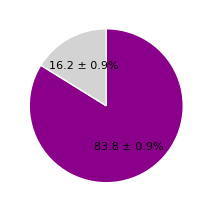

In [21]:
reload(mc)
f, ax = plt.subplots(figsize=(2.5, 2.5))
mc.plot_prop_max_variance_explained(
    results_df,
    small_model="place_direction.distance_to_goal",
    big_model="place_direction.distance_to_goal.goal.egocentric_action.velocity.head_direction.egocentric_angle_to_goal",
    colors=("darkmagenta", "lightgrey"),
    outlier_threshold=-0.6,
    print_stats=True,
    ax=ax,
)
f.savefig(FIG_SAVE_PATH / "prop_max_variance_explained_pi_chart.pdf")

## Supplementary
Additional neGLM diagnostics: fraction of neurons tuned to each feature, hyperparameter sweep, and baseline training curves.

### Proportion of neurons tuned per feature
Fraction of neurons passing the per-feature tuning significance threshold.

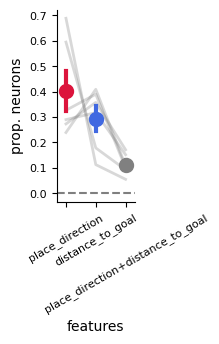

In [22]:
reload(ve)
f, ax = plt.subplots(figsize=(1, 2.5))
ve.plot_summary_pointplot(
    feature_tuned_df,
    models=models[::-1],
    ax=ax,
)
f.savefig(FIG_SAVE_PATH / "prop_neurons_variance_explained.pdf")

## Hyperparameter sweep and training
Results of the neGLM hyperparameter sweep and example training curves for the baseline model — confirming the chosen settings are stable.

In [23]:
from GridMaze.analysis.neGLM import param_sweep as ps

results_df = ps.load_sweep_results()
training_df = ps.load_sweep_training()

### Hyperparameter sweep summary
Cross-validated performance across the hyperparameter grid, with the chosen baseline highlighted.

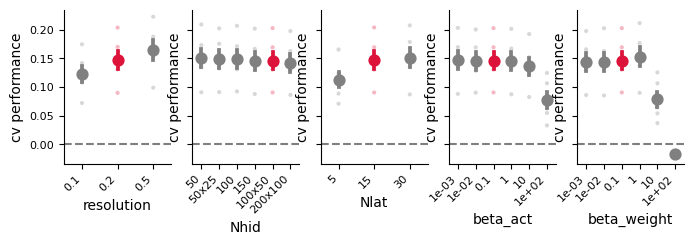

In [24]:
reload(ps)
f, axes = plt.subplots(1, 5, figsize=(8, 2), sharey=True)
ps.plot_hyperparam_sweep_summary(results_df, baseline_color="crimson", axes=axes)
f.savefig(FIG_SAVE_PATH / "hyperparam_sweep_summary.pdf")

### Baseline training curves
Train/test loss and held-out D² across epochs for the baseline model, confirming convergence without overfitting.

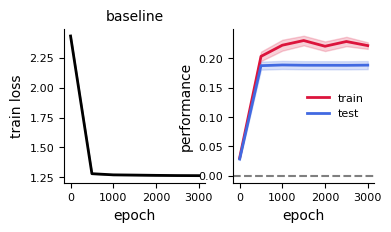

In [25]:
reload(ps)
f, axes = plt.subplots(1, 2, figsize=(4, 2))
ps.plot_training_curves(
    training_df, model_name="baseline", train_color="crimson", test_color="royalblue", loss_color="black", axes=axes
)
f.savefig(FIG_SAVE_PATH / "baseline_training_curves.pdf")